# Analyse SL-CR Experiment Results

Notebook for inspecting the merged ECLYPSE metric output, separating timeout and non-timeout events, and plotting the main Prolog reasoning metrics by topology.

## Setup

The input file is expected to be the merged parquet produced from the experiment logs. Change `RESULTS_PATH` if the file lives elsewhere.

In [26]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

RESULTS_PATH = Path(".") / "new.parquet"
PLOTS_PATH = Path(".") / "plots"
FIG_FORMAT = "pdf"
FIG_DPI = 600

MODES = ["base", "cr"]

METRICS = [
    "prolog_query_seconds",
    "placement_migrations",
]

NODES = [250, 500, 750, 1000]
COMPONENTS = [100, 200, 300]

TOPOLOGIES = [
    "ER",
    "BA",
    "IAG",
]

METRIC_LABELS = {
    "prolog_query_seconds": "Execution time [s]",
    "prolog_inferences": "Prolog inferences",
    "placement_migrations": "Migrations",
}

COL_LABELS = {
    "nodes": "Infrastructure size",
    "components": "Components",
}

EVENT_COLS = [
    # "event_id",
    "n_event",
    "callback_id",
    "value",
    "mode",
    "nodes",
    "components",
    "seed",
    "topology",
]

## Load and inspect

In [27]:
df = pd.read_parquet(RESULTS_PATH, columns=EVENT_COLS)

print(f"rows: {len(df)}")
print(f"columns: {list(df.columns)}")

display(df.head())

rows: 236300
columns: ['n_event', 'callback_id', 'value', 'mode', 'nodes', 'components', 'seed', 'topology']


,n_event,callback_id,value,mode,nodes,components,seed,topology
0,1,prolog_query_seconds,1.472888e+00,cr,1000,300,3997,IAG
1,1,prolog_inferences,2.375436e+07,cr,1000,300,3997,IAG
2,1,placement_migrations,inf,cr,1000,300,3997,IAG
3,1,is_mapped,1.000000e+00,cr,1000,300,3997,IAG
4,1,query_timeout,0.000000e+00,cr,1000,300,3997,IAG


Split into two dataframes: one for timeout events, and one for non-timeout events. The timeout events are those where `callback_id` is `query_timeout` and `value` is 1. The non-timeout events are all the others.

In [28]:
group_cols = ["mode", "nodes", "components", "seed", "topology", "n_event"]

mask_timeout_row = (
    (df["callback_id"] == "query_timeout") &
    (df["value"] == 1)
)

timeout_groups = df.loc[mask_timeout_row, group_cols].drop_duplicates()

df_marked = df.merge(
    timeout_groups.assign(has_timeout=True),
    on=group_cols,
    how="left"
)

df_marked["has_timeout"] = df_marked["has_timeout"].fillna(False).astype(bool)

df_timeout = df_marked[df_marked["has_timeout"]].drop(columns="has_timeout")
df_no_timeout = df_marked[~df_marked["has_timeout"]].drop(columns="has_timeout")

In [29]:
event_cols = ["mode", "nodes", "components", "seed", "topology", "n_event"]

events_marked = (
    df_marked[event_cols + ["has_timeout"]]
    .drop_duplicates()
)

timeout_by_topology = (
    events_marked
    .groupby("topology", as_index=False)
    .agg(
        total_events=("has_timeout", "size"),
        timeout_events=("has_timeout", "sum"),
    )
)

timeout_by_topology["timeout_percentage"] = (
    100 * timeout_by_topology["timeout_events"] / timeout_by_topology["total_events"]
)

display(timeout_by_topology)

,topology,total_events,timeout_events,timeout_percentage
0,BA,16000,61,0.381250
1,ER,16000,36,0.225000
2,IAG,15260,61,0.399738


In [30]:
def quality_summary(df: pd.DataFrame) -> pd.DataFrame:
    quality_df = df.copy()
    quality_df["is_nan"] = quality_df["value"].isna()
    quality_df["is_inf"] = np.isinf(quality_df["value"])
    quality_df["is_bad"] = quality_df["is_nan"] | quality_df["is_inf"]

    summary = (
        quality_df.groupby("callback_id", as_index=False)
        .agg(
            rows=("value", "size"),
            nan_values=("is_nan", "sum"),
            inf_values=("is_inf", "sum"),
            bad_values=("is_bad", "sum"),
        )
    )

    display(summary)
quality_summary(df_no_timeout)

,callback_id,rows,nan_values,inf_values,bad_values
0,is_mapped,47102,0,0,0
1,placement_migrations,47102,0,12333,12333
2,prolog_inferences,47102,0,11868,11868
3,prolog_query_seconds,47102,0,11873,11873
4,query_timeout,47102,0,0,0


In [31]:
df_plot = df_no_timeout.copy()
df_plot = df_plot.replace([np.inf, -np.inf], np.nan)
df_plot = df_plot.dropna(subset=["value"])

In [32]:
NODES_FILTER = None
COMPONENTS_FILTER = [100, 200, 300]
MODE_FILTER = None
TOPOLOGY_FILTER = None
N_EVENT_FILTER = 2


def apply_filters(data: pd.DataFrame) -> pd.DataFrame:
    out = data.copy()
    if N_EVENT_FILTER is not None:
        out = out[out["n_event"] >= N_EVENT_FILTER]
    if NODES_FILTER is not None:
        out = out[out["nodes"] == NODES_FILTER]
    if COMPONENTS_FILTER is not None:
        out = out[out["components"].isin(COMPONENTS_FILTER)]
    if MODE_FILTER is not None:
        out = out[out["mode"] == MODE_FILTER]
    if TOPOLOGY_FILTER is not None:
        out = out[out["topology"] == TOPOLOGY_FILTER]
    return out

print(f"rows before filters: {len(df_plot)}")
plot_df = apply_filters(df_plot)
plot_df["value"] = pd.to_numeric(plot_df["value"], errors="coerce")

print(f"rows after filters: {len(plot_df)}")

rows before filters: 199436
rows after filters: 150750


In [33]:
def remove_outliers_iqr(group, col="value", k=1.5):
    q1 = group[col].quantile(0.25)
    q3 = group[col].quantile(0.75)
    iqr = q3 - q1

    if iqr == 0 or pd.isna(iqr):
        return group

    lower = q1 - k * iqr
    upper = q3 + k * iqr

    return group[
        (group[col] >= lower) &
        (group[col] <= upper)
    ]

def remove_outliers_zscore(group, col="value", threshold=3):
    std = group[col].std()

    if std == 0 or pd.isna(std):
        return group

    z = (group[col] - group[col].mean()) / std

    return group[np.abs(z) < threshold]


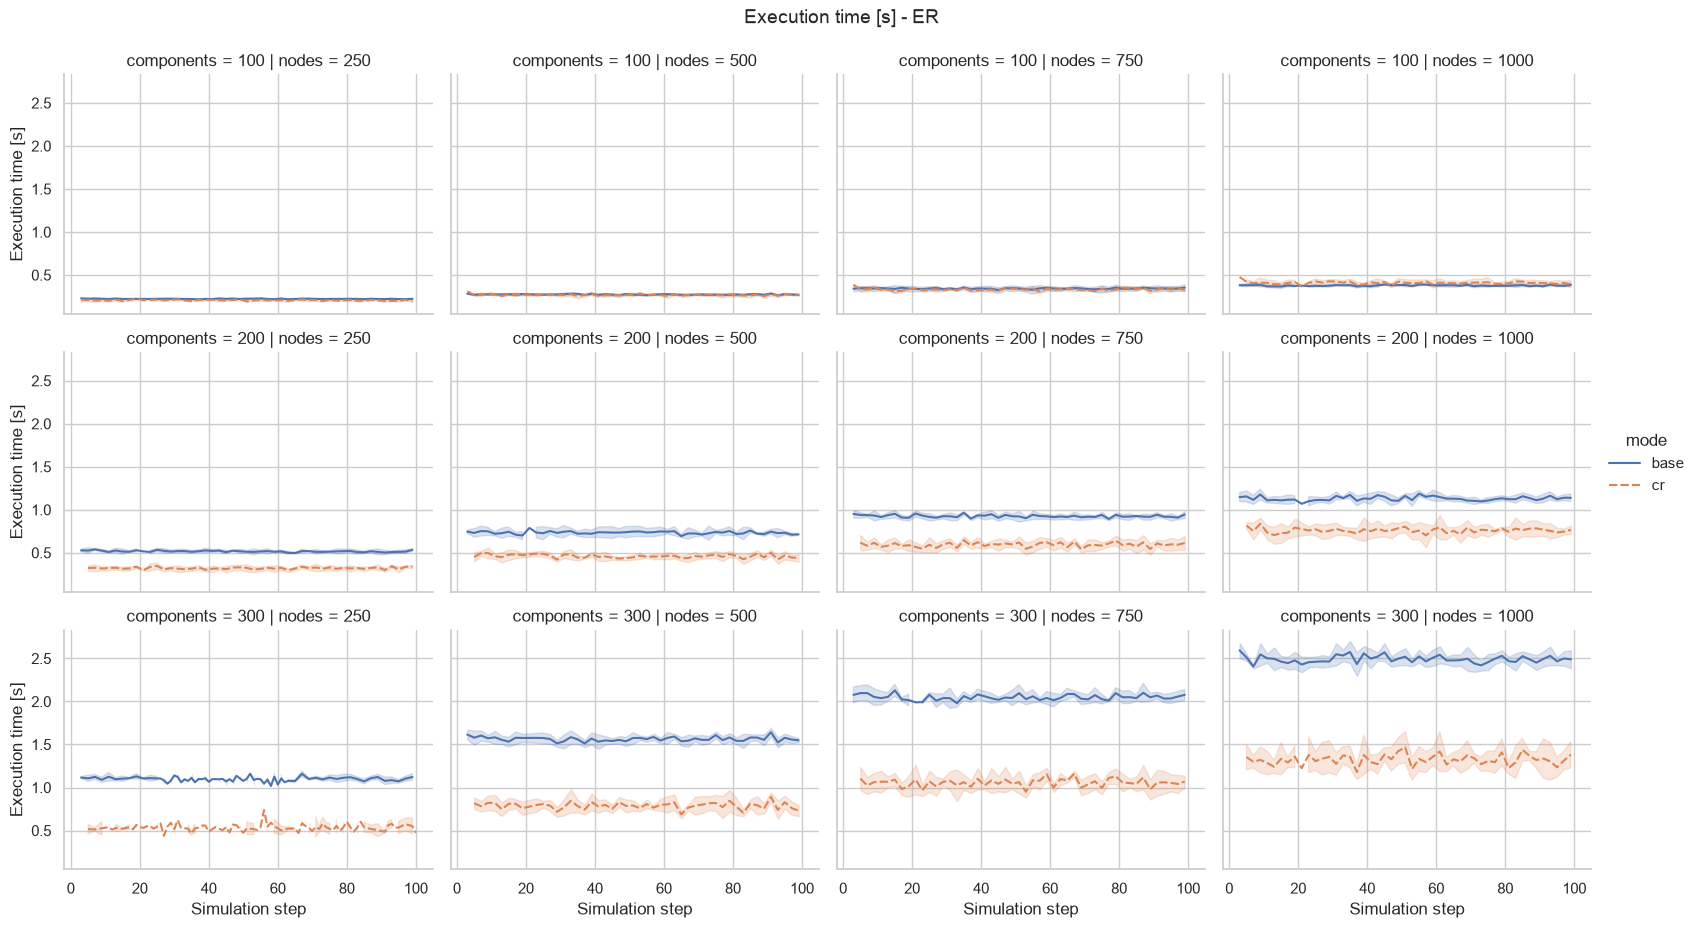

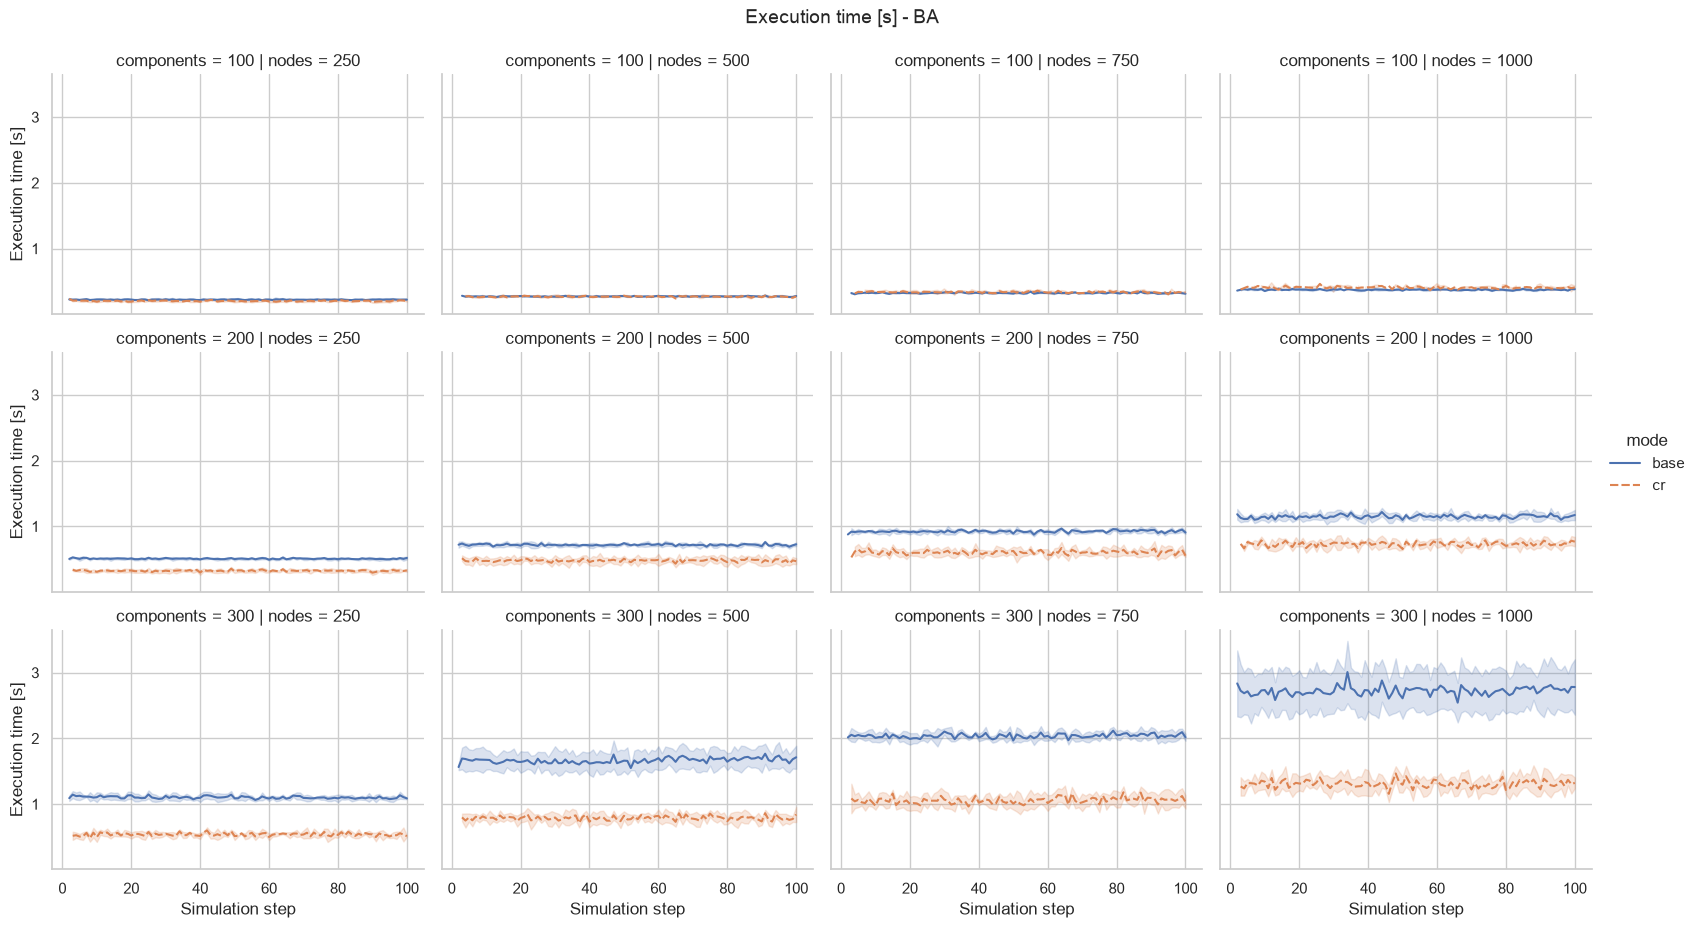

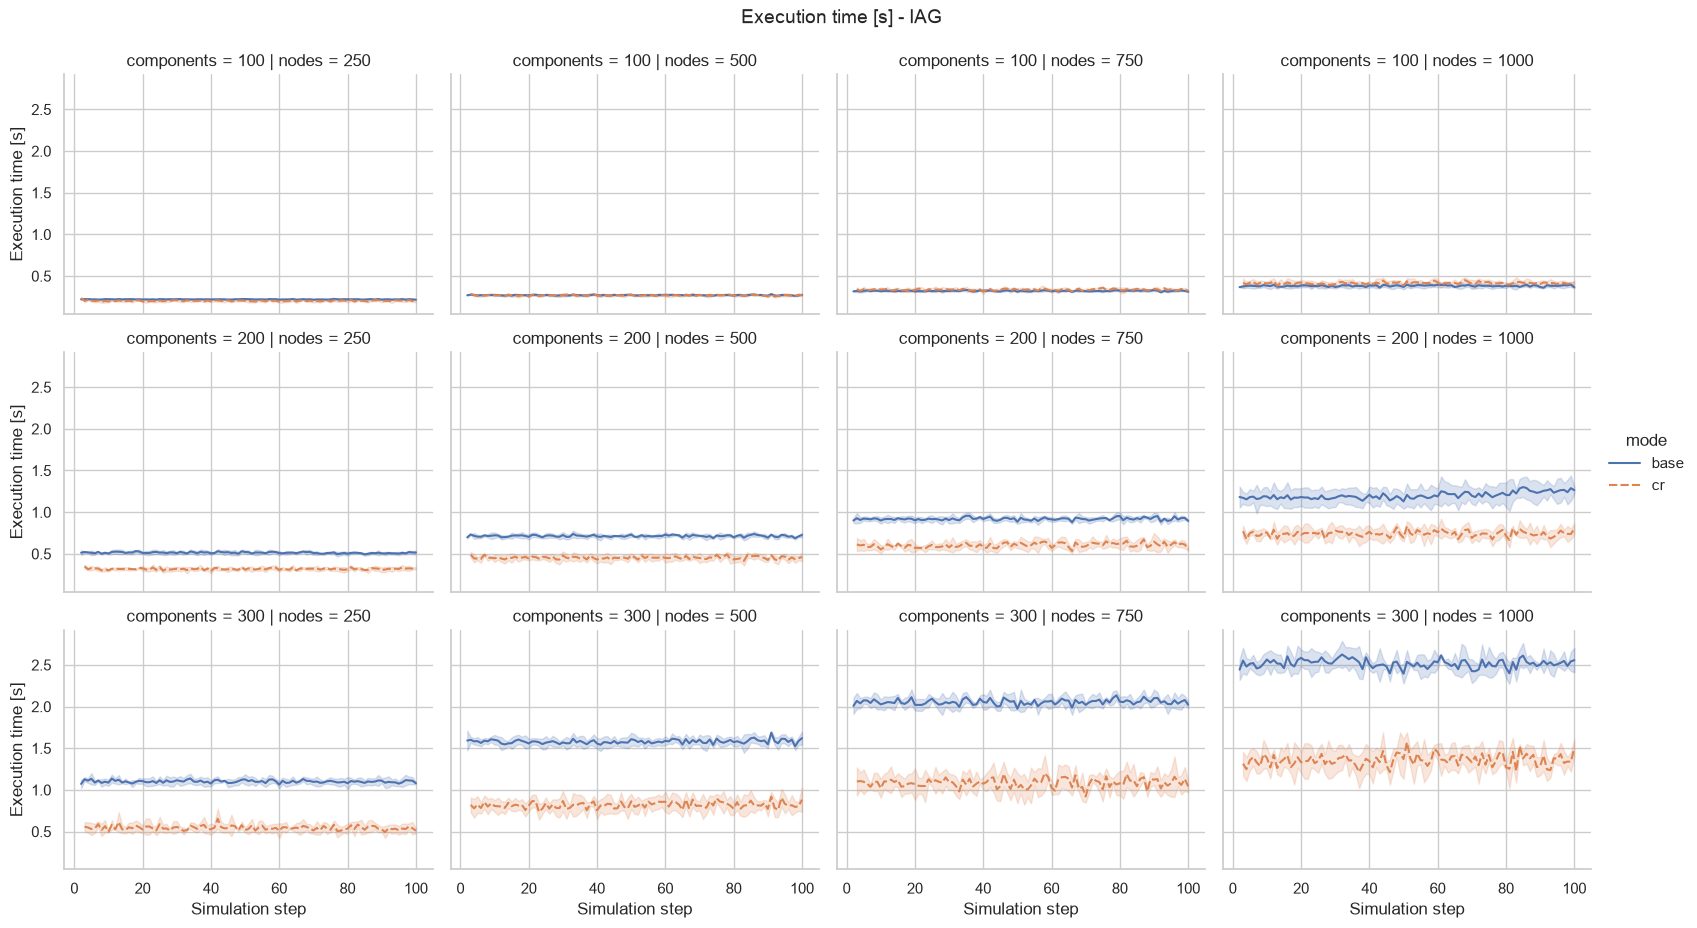

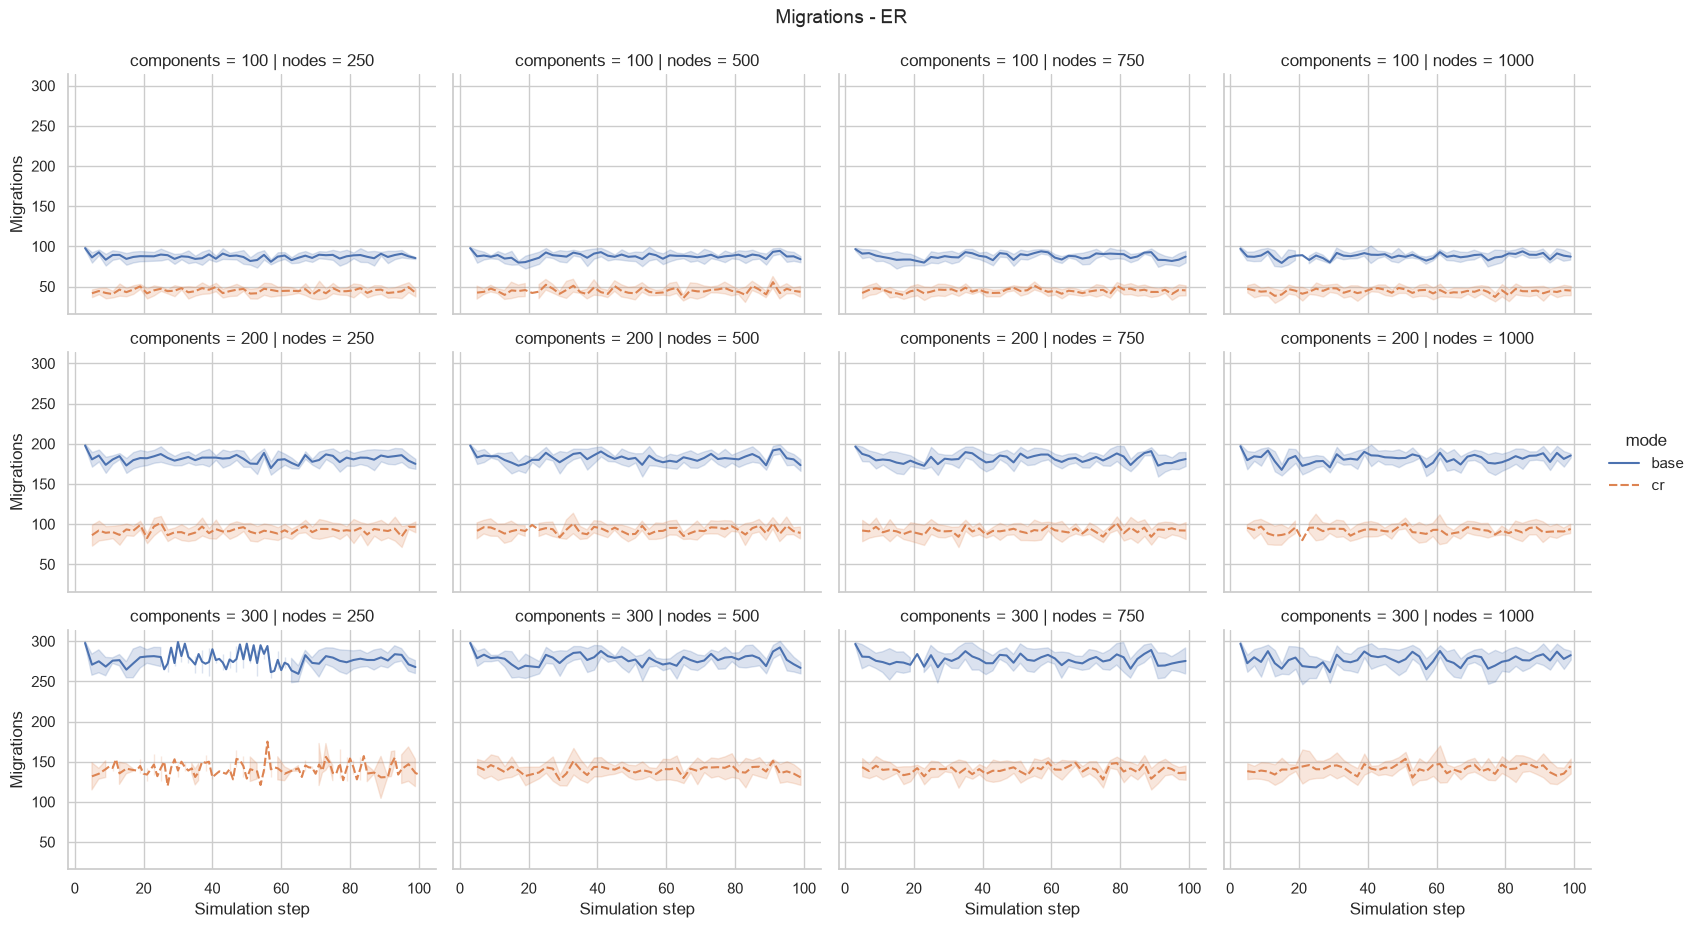

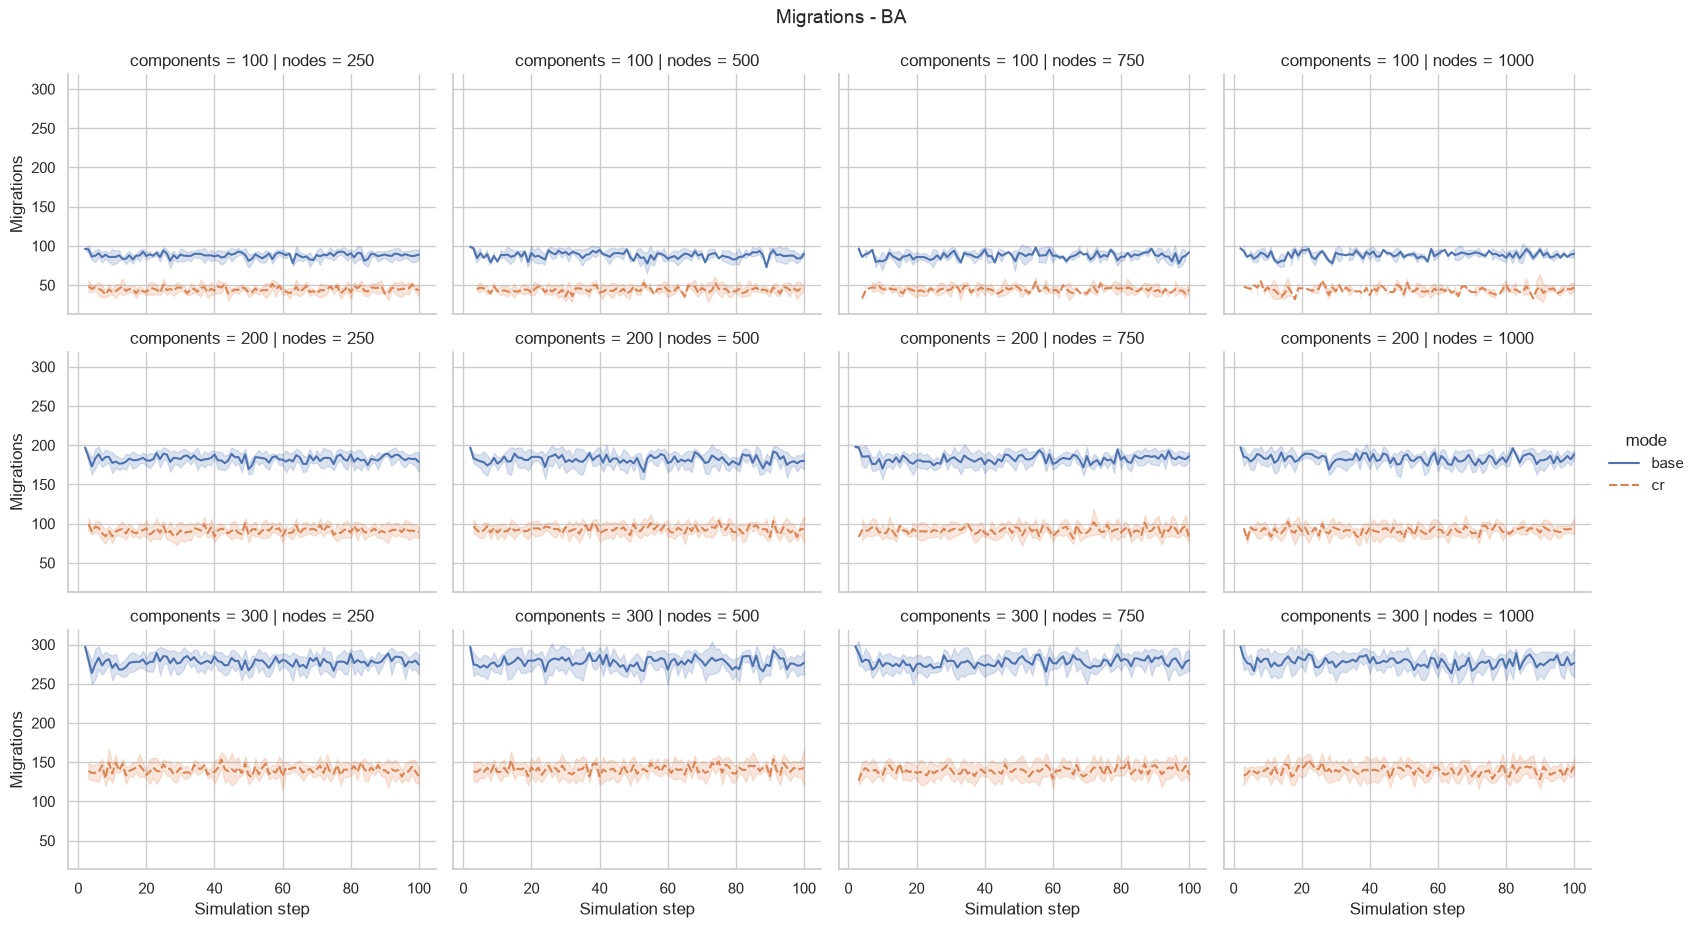

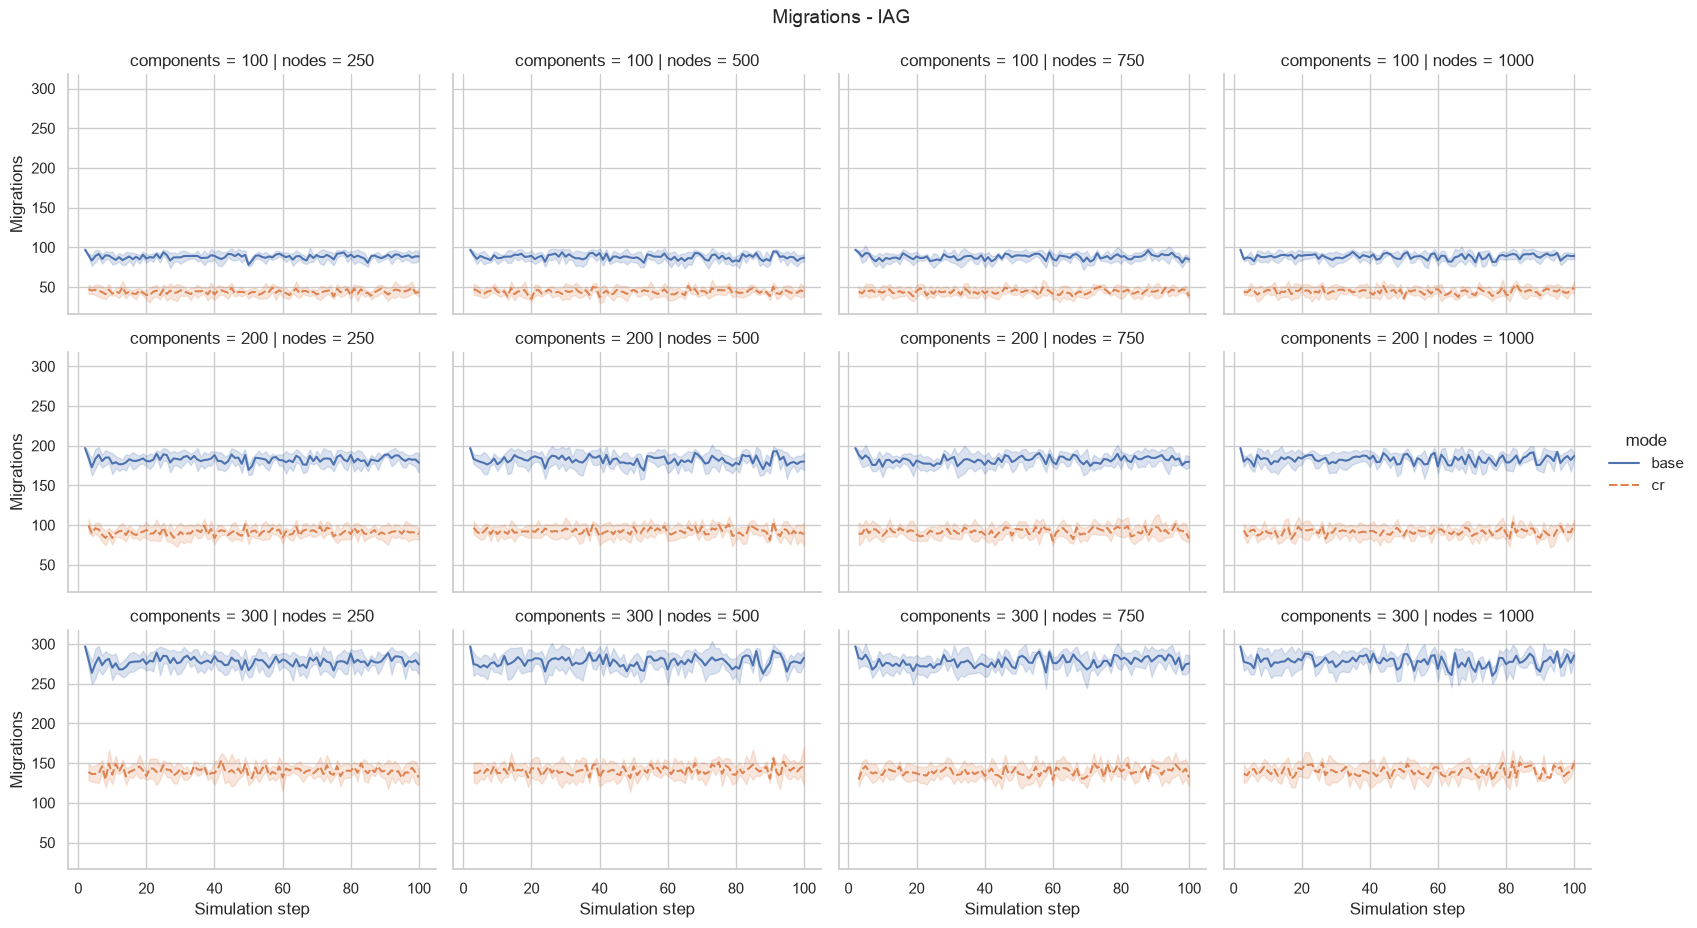

In [34]:
outlier_group_cols = ["mode", "nodes", "components"]

for metric in METRICS:
    for topology in TOPOLOGIES:

        data = plot_df[
            (plot_df["callback_id"] == metric) &
            (plot_df["topology"] == topology)
        ].copy()

        data = data.groupby(outlier_group_cols).apply(remove_outliers_iqr).copy()

        if data.empty:
            print(f"{metric} - {topology}: no data after outlier removal")
            continue

        g = sns.relplot(
            data=data,
            x="n_event",
            y="value",
            hue="mode",
            style="mode",
            col="nodes",
            row="components",
            kind="line",
            errorbar="sd",
            marker=None,
            height=3.0,
            aspect=1.35,
            facet_kws={"sharex": True, "sharey": True},
        )

        g.set_axis_labels("Simulation step", METRIC_LABELS[metric])
        g.set_titles(
            row_template="components = {row_name}",
            col_template="nodes = {col_name}"
        )

        g.figure.suptitle(
            f"{METRIC_LABELS[metric]} - {topology}",
            y=1.03,
            fontsize=14
        )

        for ax in g.axes.flat:
            ax.grid(True)

        plt.show()

In [35]:
# outlier_group_cols = ["mode", "nodes", "components", "topology"]
# lineplot_df = plot_df.copy()

# lineplot_df["nodes"] = lineplot_df["nodes"].astype(str)
# lineplot_df["components"] = lineplot_df["components"].astype(str)

# X_TICKS = sorted(lineplot_df["nodes"].unique(), key=lambda x: int(x))
# HUE_ORDER = sorted(lineplot_df["components"].unique(), key=lambda x: int(x))

# Y_LIMS = {
#     "placement_migrations": (0, 300),
#     "prolog_query_seconds": (0, 3),
# }

# def lineplot(
#     plot_df: pd.DataFrame,
#     metric: str,
#     mode: str,
#     topology: str
# ) -> None:
#     data = plot_df[
#             (plot_df["callback_id"] == metric) &
#             (plot_df["mode"] == mode) &
#             (plot_df["topology"] == topology)
#         ].copy()
    
#     data = data.groupby(outlier_group_cols).apply(remove_outliers_iqr).copy()

#     if data.empty:
#         print(f"No data for metric={metric}, mode={mode}, topology={topology}")
#     else:
#         plt.figure(figsize=(7, 4.5))

#         sns.lineplot(
#             data=data,
#             x="nodes",
#             y="value",
#             hue="components",
#             style="components",
#             marker="o",
#             # errorbar="sd",
#             hue_order=HUE_ORDER
#         )

#         plt.title(f"mode={mode} | topology={topology}")
#         plt.xlabel(COL_LABELS["nodes"])
#         plt.xticks(ticks=range(len(X_TICKS)), labels=X_TICKS)
#         plt.ylabel(METRIC_LABELS[metric])
#         plt.ylim(Y_LIMS.get(metric))
#         plt.grid(True)
#         plt.legend(title=COL_LABELS["components"])

#         plt.tight_layout()
#         fig_path = PLOTS_PATH / f"{metric}" / f"{mode}" / f"{topology}"
#         fig_path.parent.mkdir(parents=True, exist_ok=True)
#         plt.savefig(fig_path.with_suffix(f".{FIG_FORMAT}"), dpi=FIG_DPI)
#         # plt.show()

# for metric in METRICS:
#     for mode in MODES:
#         for topology in TOPOLOGIES:
#             lineplot(lineplot_df, metric, mode, topology)

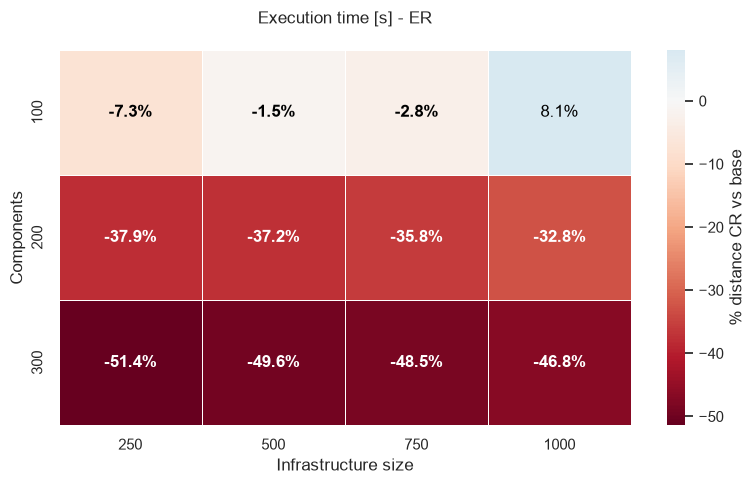

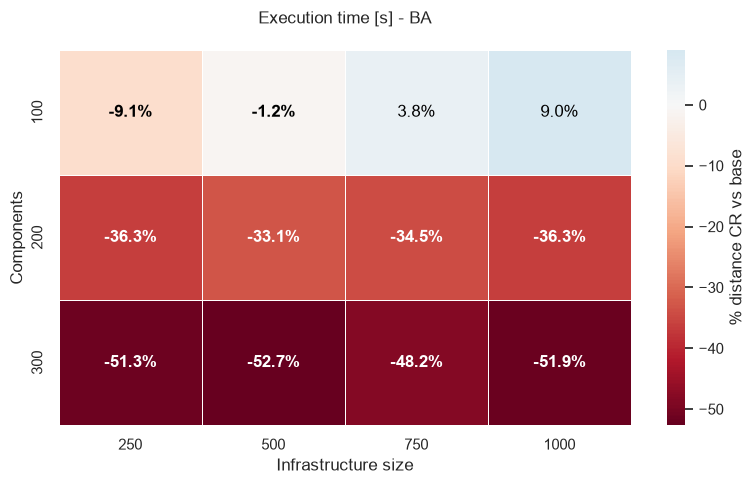

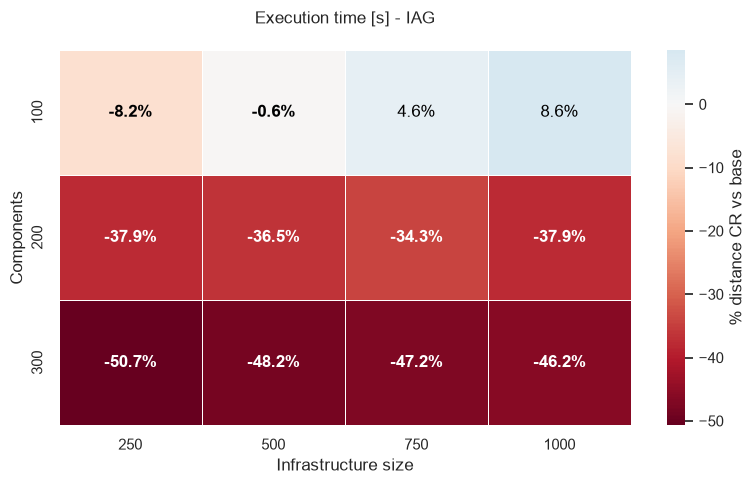

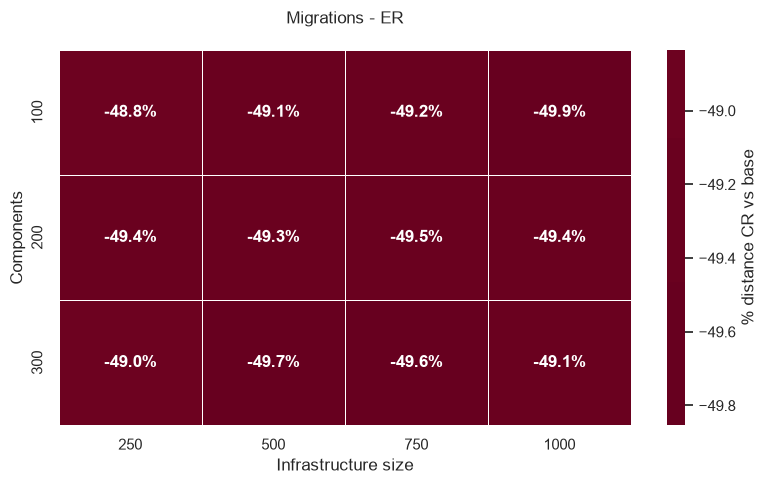

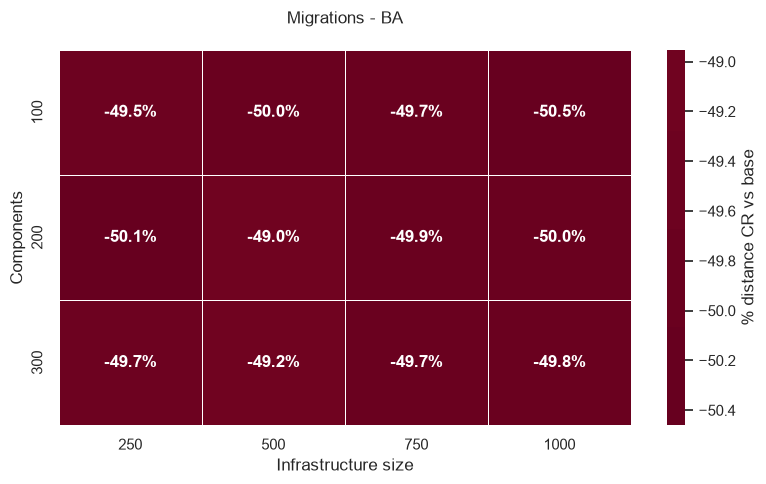

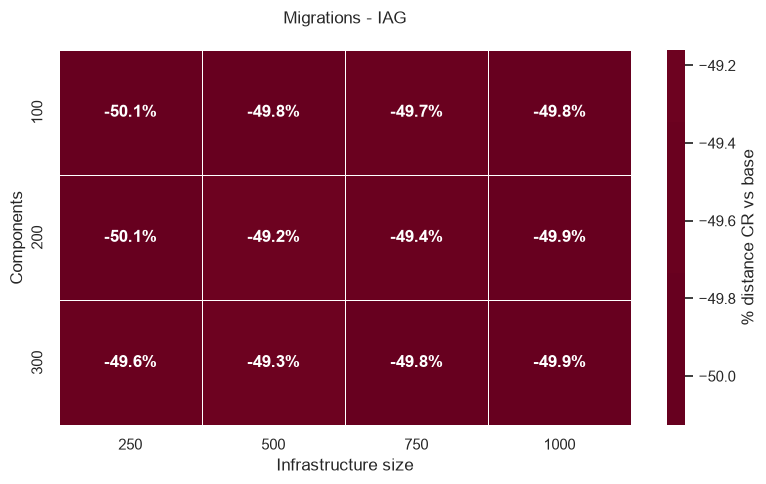

In [36]:
base_mode = MODES[0]
cr_mode = MODES[1]

def heatmap(plot_df: pd.DataFrame, metric: str, topology: str):
    data = plot_df[
        (plot_df["callback_id"] == metric) &
        (plot_df["topology"] == topology) &
        (plot_df["mode"].isin([base_mode, cr_mode]))
    ].copy()

    data = data.groupby(outlier_group_cols).apply(remove_outliers_iqr).copy()

    agg = (
        data
        .groupby(["nodes", "components", "mode"], as_index=False)
        .agg(mean_value=("value", "mean"))
    )

    wide = agg.pivot_table(
        index=["nodes", "components"],
        columns="mode",
        values="mean_value"
    ).reset_index()

    # Distanza percentuale con segno: positiva se cr > base
    wide["pct_distance"] = np.where(
        wide[base_mode] != 0,
        100 * (wide[cr_mode] - wide[base_mode]) / wide[base_mode],
        np.nan
    )

    # Matrice heatmap: y=components, x=nodes
    heatmap_data = wide.pivot(
        index="components",
        columns="nodes",
        values="pct_distance"
    )

    # annot_data = heatmap_data.map(lambda x: "" if pd.isna(x) else f"{x:.1f}%"    )

    plt.figure(figsize=(8, 5))
    ax = sns.heatmap(
        heatmap_data,
        annot=False,
        # fmt = "",
        cmap="RdBu",
        center=0,
        linewidths=0.5,
        cbar_kws={"label": "% distance CR vs base"}
    )

    mesh = ax.collections[0]
    cmap = mesh.cmap
    norm = mesh.norm

    for i, component in enumerate(heatmap_data.index):
        for j, node in enumerate(heatmap_data.columns):
            value = heatmap_data.loc[component, node]

            if pd.isna(value):
                continue

            # Colore della cella
            rgba = cmap(norm(value))
            r, g, b, _ = rgba

            # Luminanza percepita: testo bianco su celle scure, nero su celle chiare
            luminance = 0.299 * r + 0.587 * g + 0.114 * b
            text_color = "white" if luminance < 0.5 else "black"

            ax.text(
                j + 0.5,
                i + 0.5,
                f"{value:.1f}%",
                ha="center",
                va="center",
                fontweight="bold" if value < 0 else "normal",
                color=text_color
            ) 

    plt.title(f"{METRIC_LABELS[metric]} - {topology}\n")
    plt.xlabel(COL_LABELS["nodes"])
    plt.ylabel(COL_LABELS["components"])

    plt.tight_layout()
    fig_path = PLOTS_PATH / f"{metric}" / "heatmap" / f"{topology}"
    fig_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(fig_path.with_suffix(f".{FIG_FORMAT}"), dpi=FIG_DPI)
    # plt.show()

for metric in METRICS:
    for topology in TOPOLOGIES:
        heatmap(plot_df, metric, topology)

In [37]:
# migration_metric = "placement_migrations"      # cambia con il tuo callback_id reale
# execution_metric = "prolog_query_seconds"       # cambia con il tuo callback_id reale

# id_cols = ["mode", "nodes", "components", "topology", "n_event"]

# def prova(plot_df: pd.DataFrame, nodes: int, components: int, migration_metric: str, execution_metric: str, topology: str) -> None:
#     data = plot_df[
#         (plot_df["topology"] == topology) & 
#         (plot_df["nodes"] == nodes) & 
#         (plot_df["components"] == components) & 
#         (plot_df["callback_id"].isin([migration_metric, execution_metric]))
#     ].copy()

#     data = data.groupby(id_cols).apply(remove_outliers_iqr).copy()

#     # Wide format: una colonna per metrica
#     wide = (
#         data
#         .pivot_table(
#             index=id_cols,
#             columns="callback_id",
#             values="value",
#             aggfunc="mean"
#         )
#         .reset_index()
#     )

#     wide = wide.rename(columns={
#         migration_metric: "n_migrations",
#         execution_metric: "execution_time"
#     })

#     wide = wide.dropna(subset=["n_migrations", "execution_time"])

#     plt.figure(figsize=(7, 4.5))

#     sns.scatterplot(
#         data=wide,
#         x="n_migrations",
#         y="execution_time",
#         hue="mode",
#         style="mode",
#         s=70,
#         alpha=0.8
#     )

#     plt.xlabel("Number of migrations")
#     plt.ylabel("Execution time")
#     plt.title(f"topology={topology} | nodes={nodes} | components={components}")
#     plt.grid(True)

#     plt.tight_layout()
#     plt.show()

# for topology in TOPOLOGIES:
#     for nodes in NODES:
#         for components in COMPONENTS:
#             prova(plot_df, nodes, components, migration_metric, execution_metric, topology)

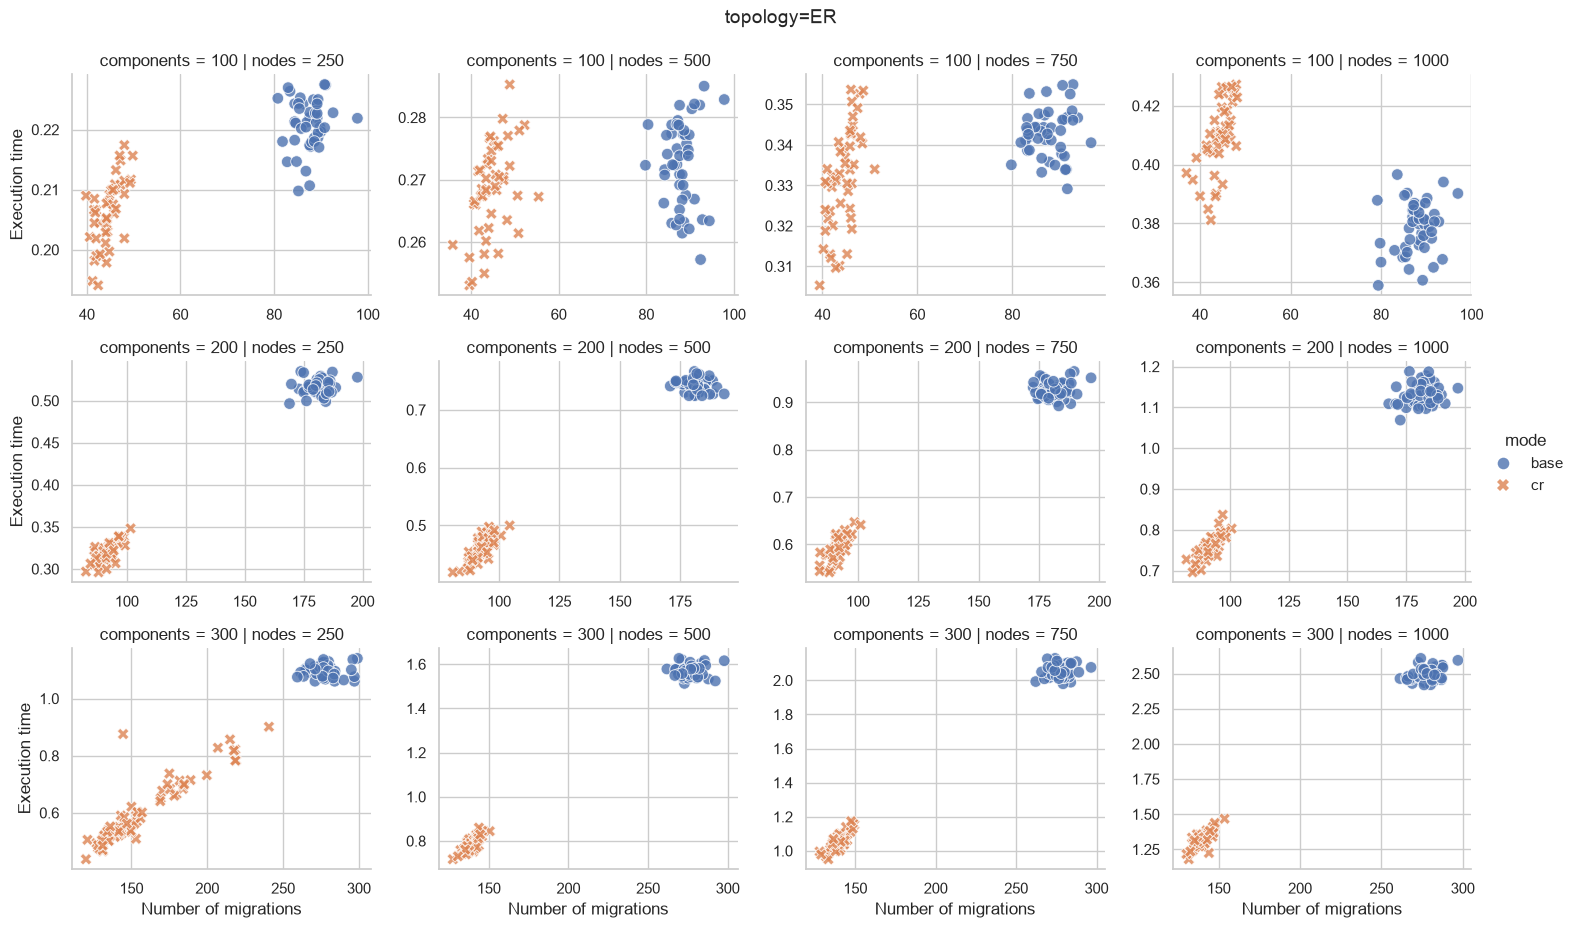

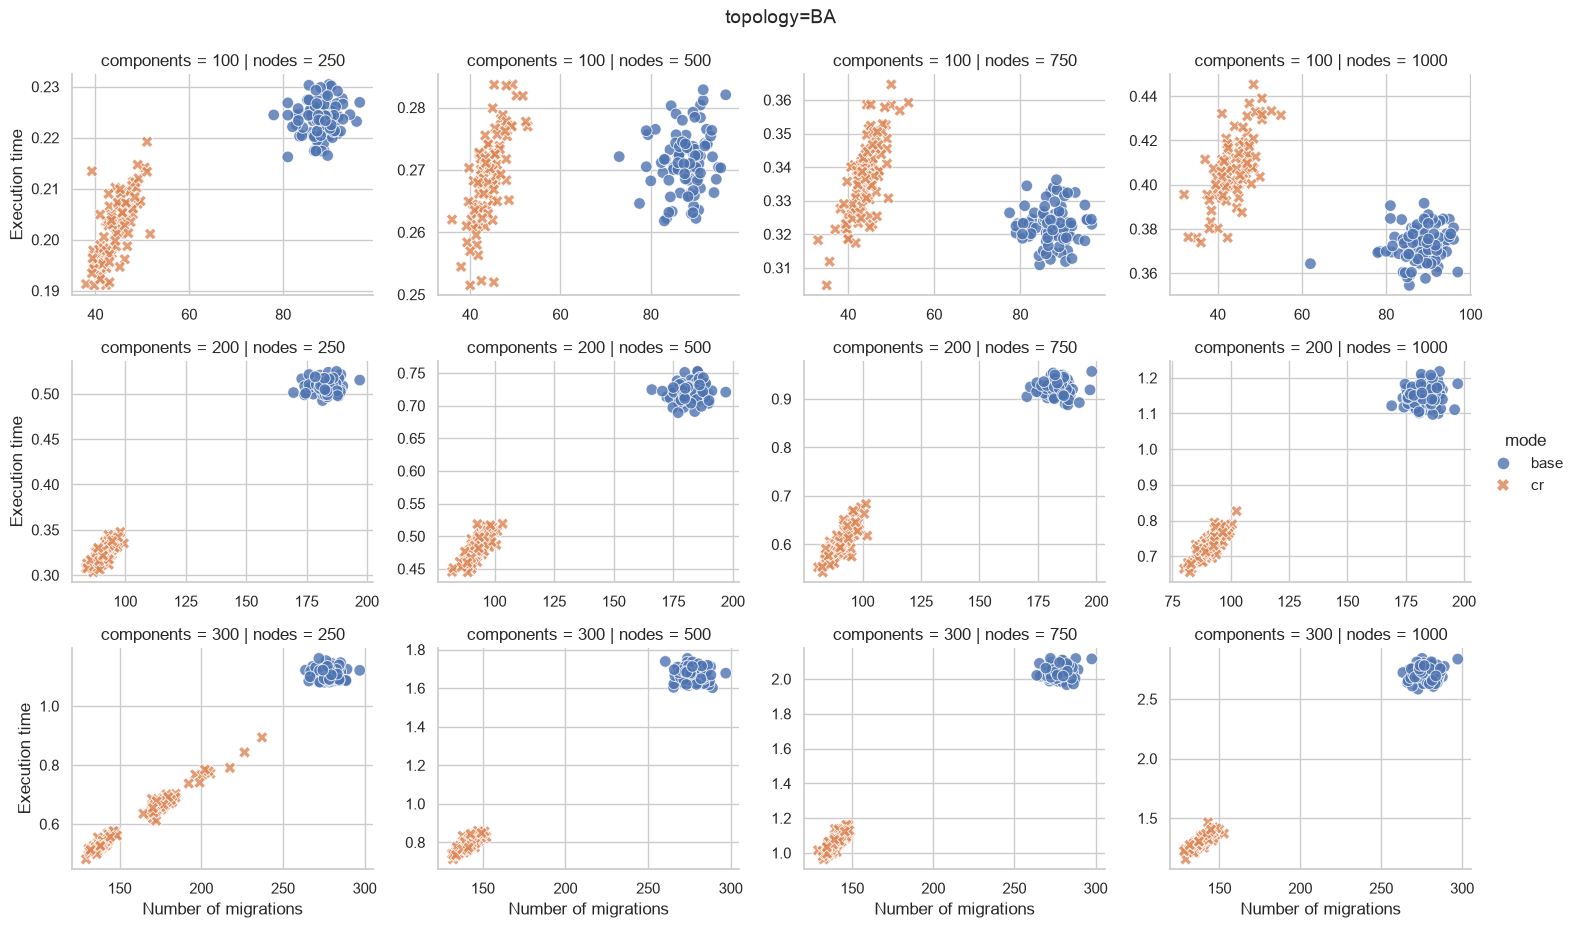

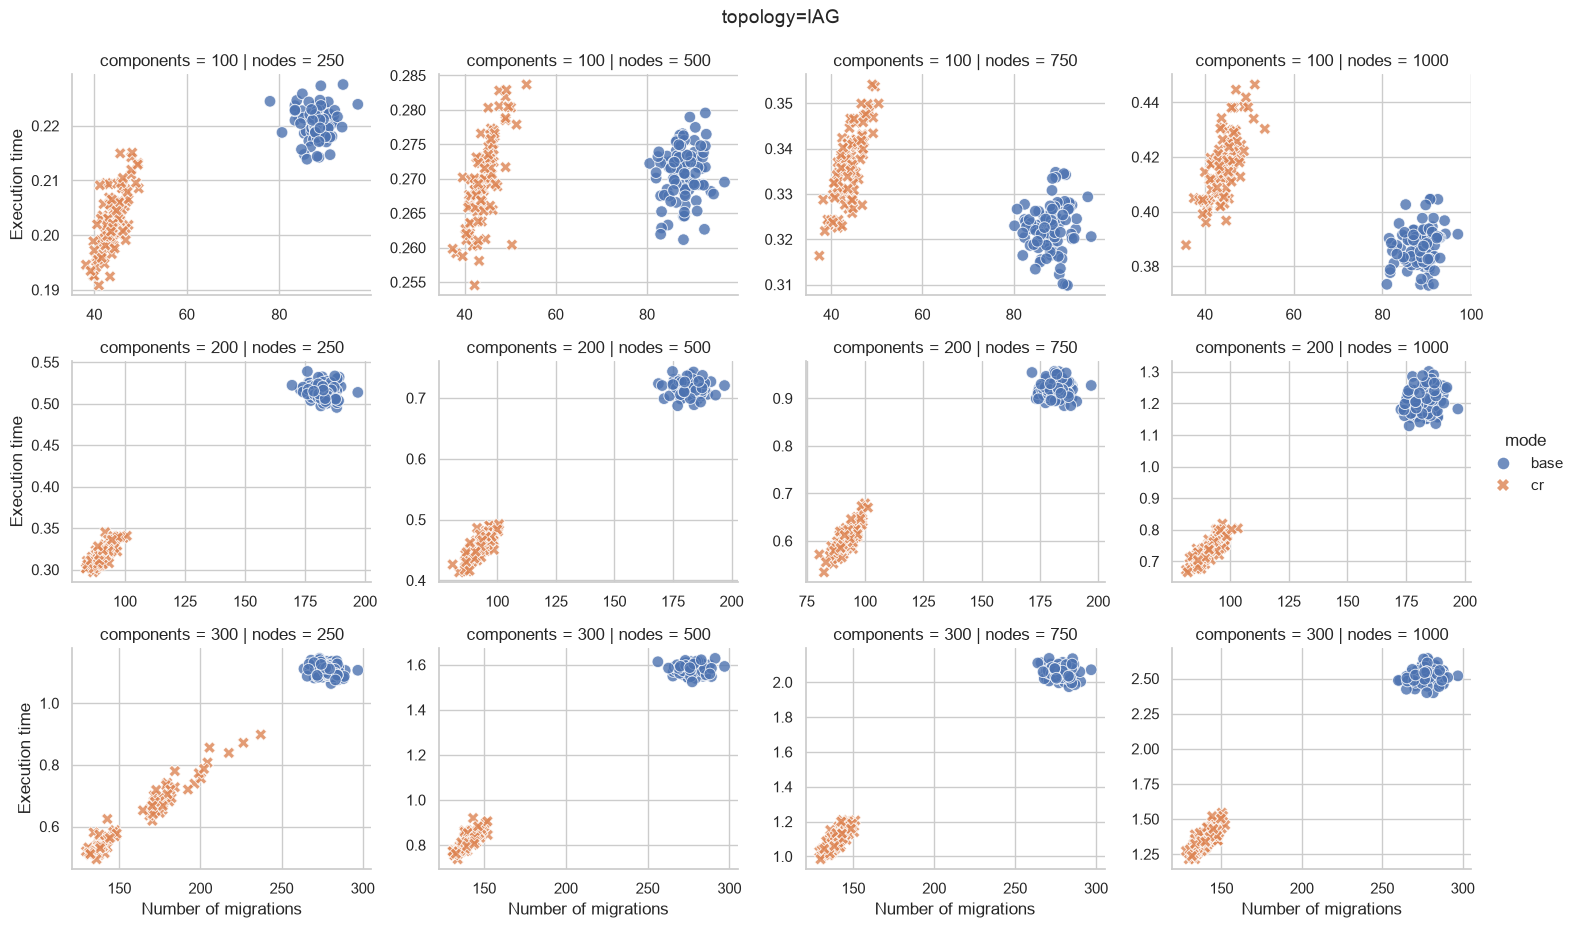

In [52]:
migration_metric = "placement_migrations"
execution_metric = "prolog_query_seconds"

id_cols = ["mode", "nodes", "components", "topology", "n_event"]
out_cols = ["mode", "nodes", "components", "topology"]

def plot_migrations_vs_execution_relplot(
    plot_df: pd.DataFrame,
    migration_metric: str,
    execution_metric: str,
    topology: str,
) -> None:

    data = plot_df[
        (plot_df["topology"] == topology) &
        (plot_df["callback_id"].isin([migration_metric, execution_metric]))
    ].copy()

    if data.empty:
        print(f"No data for topology={topology}")
        return

    # Wide format: una colonna per metrica
    wide = (
        data
        .pivot_table(
            index=id_cols,
            columns="callback_id",
            values="value",
            aggfunc="mean"
        )
        .reset_index()
    )

    wide = wide.rename(columns={
        migration_metric: "n_migrations",
        execution_metric: "execution_time"
    })

    wide = wide.dropna(subset=["n_migrations", "execution_time"])
    wide = wide.groupby(out_cols).apply(remove_outliers_iqr, col="execution_time").copy()

    if wide.empty:
        print(f"No paired data for topology={topology}")
        return

    g = sns.relplot(
        data=wide,
        x="n_migrations",
        y="execution_time",
        hue="mode",
        style="mode",
        col="nodes",
        row="components",
        kind="scatter",
        s=70,
        alpha=0.8,
        height=3.0,
        aspect=1.25,
        facet_kws={
            "sharex": False,
            "sharey": False,
        },
    )

    g.set_axis_labels("Number of migrations", "Execution time")
    g.set_titles(
        row_template="components = {row_name}",
        col_template="nodes = {col_name}"
    )

    g.figure.suptitle(f"topology={topology}",y=1.03,fontsize=14)

    for ax in g.axes.flat:
        ax.grid(True)

    plt.show()


for topology in TOPOLOGIES:
    plot_migrations_vs_execution_relplot(
        plot_df=plot_df,
        migration_metric=migration_metric,
        execution_metric=execution_metric,
        topology=topology,
    )